# Image Representation

(1213, 1546, 3)


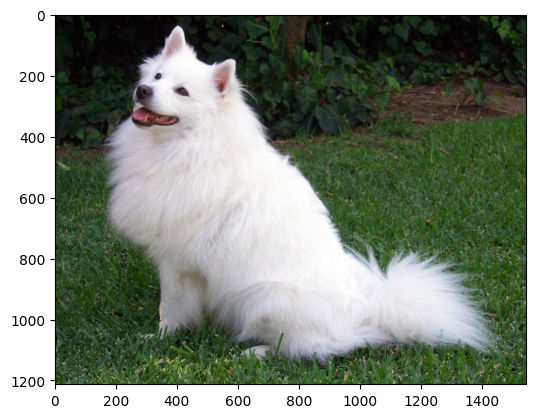

In [38]:
#1. Raw Image Load

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

img=Image.open('dog.jpg').convert('RGB')

print(np.array(img).shape)
plt.imshow(img)

In [39]:
#2. Preprocess Image

import torch
import torch.nn as nn
import torchvision
import torchvision. transforms as T

preprocess = T.Compose([
    T.Resize((224, 224)), #무슨 기법 사용?
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    #ImageNet의 전체 데이터에 대한 평균, 분산값
    ])

x = preprocess (img)
print(x.shape)
x = x.unsqueeze(0) #1을 가진 새로운 차원을 하나 만듦
print(x.shape) #최종으로 모델에 들어가게 될 tensor의 shape

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


In [40]:
#3. ResNet50 model Load

resnet = torchvision.models.resnet50(weights='DEFAULT')
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [41]:
#4. Calculate Image Embedding

x = preprocess(img).unsqueeze(0)
print(x.shape)
x=resnet.maxpool(resnet.relu(resnet.bn1(resnet.conv1(x))))
print(x.shape)
x=resnet.layer1(x)
print(x.shape)
x=resnet.layer2(x)
print(x.shape)
x=resnet.layer3(x)
print(x.shape)
x=resnet.layer4(x)
print(x.shape)
x=resnet.avgpool(x)
print(x.shape)
print(torch.flatten(x,1).shape)

torch.Size([1, 3, 224, 224])
torch.Size([1, 64, 56, 56])
torch.Size([1, 256, 56, 56])
torch.Size([1, 512, 28, 28])
torch.Size([1, 1024, 14, 14])
torch.Size([1, 2048, 7, 7])
torch.Size([1, 2048, 1, 1])
torch.Size([1, 2048])


In [42]:
#+@압축률
5625894/2048

2747.0185546875

# Text Representation

In [43]:
#1. Install gensim library

!pip install gensim

In [44]:
#2. Download GloVe pre-trained weight matrix

import gensim.downloader as api
glove=api.load('glove-wiki-gigaword-300')

In [45]:
print(len(glove))
print(glove.vector_size)

400000
300


In [46]:
#3. Compute cosine similarity between GloVe embedding vectors

cos = nn.CosineSimilarity(dim=0)
dog = torch.tensor(glove['dog'])
print(dog.shape)
cat = torch.tensor(glove['cat'])
print(cat.shape)
person = torch.tensor(glove['person'])
print(person.shape)

print(cos(dog,cat))
print(cos(dog,person))
print(cos(torch.tensor(glove['have']), torch.tensor(glove['has'])))

torch.Size([300])
torch.Size([300])
torch.Size([300])
tensor(0.6817)
tensor(0.3366)
tensor(0.7619)


In [47]:
#4. Convert raw text sentence into GloVe word embeddings

sentence = 'a dog is sitting on the grass'
tokens = sentence.split()
print(tokens)

#키(단어)를 인덱스로
ids = [glove.key_to_index[w] for w in tokens]
print(ids)

#인덱스를 벡터로
vecs = torch.tensor(glove.vectors[ids])
print(vecs.shape)

['a', 'dog', 'is', 'sitting', 'on', 'the', 'grass']
[7, 2926, 14, 2995, 13, 0, 4614]
torch.Size([7, 300])


In [48]:
#5. Prepare nn.Embedding & LSTM

glove_vectors = torch.FloatTensor(glove.vectors)
print(glove_vectors.shape)
embed = nn.Embedding.from_pretrained(glove_vectors)
lstm = nn.LSTM(300, 256, batch_first=True)
#256은 hidden state에서의 길이

torch.Size([400000, 300])


In [51]:
#6. Calculate sentence embedding

x = torch.tensor(ids).unsqueeze(0)
print(x.shape)
#각 단어의 인덱스 값이 들어있음

x = embed(x)
print(x.shape)
#300차원이 반환됨을 확인

out, (hidden, cell) = lstm(x)
print(out.shape)
print(hidden.shape)
print(cell.shape)
print(hidden.squeeze(0).shape)
#hidden이 맨 마지막으로 출력되는 hidden 값.
#cell은 잘 안 쓰이는데 그냥 마지막으로 출력된 값?으로 이해해라

torch.Size([1, 7])
torch.Size([1, 7, 300])
torch.Size([1, 7, 256])
torch.Size([1, 1, 256])
torch.Size([1, 1, 256])
torch.Size([1, 256])


# Speech Representation

torch.Size([1, 268985]) 8000
33.623125


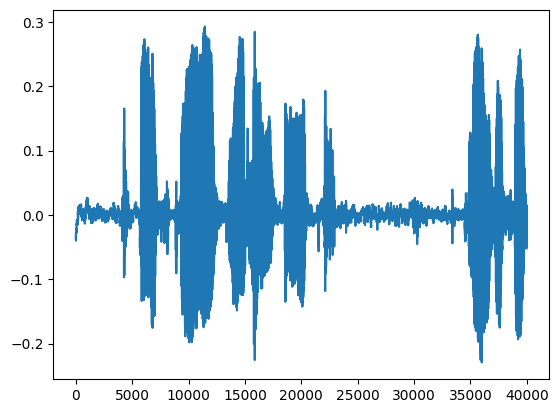

In [52]:
#1. Raw speech load

import torchaudio
wav, sr = torchaudio.load('sample_speech.wav')
print(wav.shape, sr)
print(268985/8000)
plt.plot(wav[0, :40000].numpy())
plt.show()

torch.Size([1, 128, 1345])


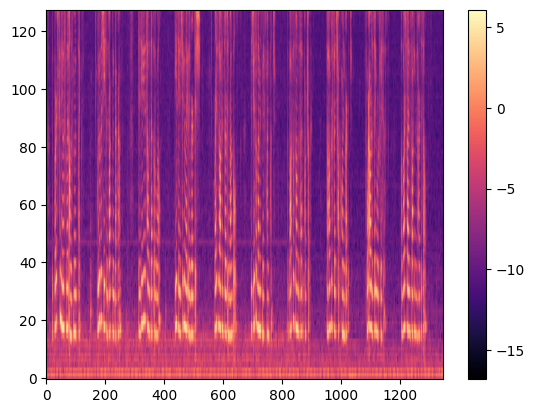

In [54]:
#2. Convert to Mel-spectrogram & visualize

mel_transform = torchaudio.transforms.MelSpectrogram(sr)
x = mel_transform(wav)
print(x.shape)
#128이 주파수 대역, 윈도우를 통해 압축되어 1345가 됨

x = torch.log(x + 1e-9) #크기가 커서 로그로 압축 필요
plt.imshow(x[0].numpy(), aspect='auto', origin='lower', cmap='magma')
plt.colorbar()
plt.show()